# SLIIT IT3051 - EV Battery PHM Dual-Task System
## Week 2 - Task 2: Linear Baselines, Decision Threshold Tuning & Master Leaderboard
### **Assigned Member: Person D**

---
### Overview & Objectives:
Establish classification baselines, evaluate cost-sensitive linear models, perform decision threshold tuning for safety, and compile the Master Evaluation Leaderboard.


### 0. Environment Setup & Data Partition Loading
Execute this cell to load the verified preprocessed matrices.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

def load_data():
    dataset_path = 'ev battery_failure  Dataset.csv'
    for p in [dataset_path, f'../{dataset_path}', f'../../{dataset_path}']:
        if os.path.exists(p):
            dataset_path = p
            break

    df = pd.read_csv(dataset_path)

    # 7 Domain Features
    df['temperature_spread'] = df['cell_temperature_max'] - df['cell_temperature_avg']
    df['efficiency_gap'] = (df['charge_efficiency'] - df['discharge_efficiency']).abs()
    df['health_loss_interaction'] = (df['battery_health_percent'] * df['capacity_loss_percent']) / 100.0
    df['resistance_per_1000_cycles'] = (df['internal_resistance'] / (df['cycle_count'] + 1.0)) * 1000.0
    df['c_rate_proxy'] = df['average_charge_power_kw'] / (df['battery_capacity_kwh'] + 1e-5)
    df['cell_voltage_spread'] = df['cell_voltage_std'] / (df['cell_voltage_avg'] + 1e-5)
    df['stress_index'] = df['aggressive_acceleration_score'] * df['hard_braking_score']

    id_cols = ['vehicle_id', 'battery_serial']
    target_rul = 'predicted_remaining_life_cycles'
    target_fail = 'battery_failure'

    excluded = id_cols + [target_rul, target_fail]
    features = [c for c in df.columns if c not in excluded]

    num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[features].select_dtypes(include=['object', 'string', 'category']).columns.tolist()

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

    # Task 1 Splits (RUL)
    df_t1 = df[df[target_rul].notnull()].copy()
    X1_tr, X1_te, y1_train, y1_test = train_test_split(df_t1[features], df_t1[target_rul], test_size=0.20, random_state=42)
    ct1 = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)], verbose_feature_names_out=False)
    X1_train = ct1.fit_transform(X1_tr)
    X1_test = ct1.transform(X1_te)

    # Task 2 Splits (Failure)
    X2_tr, X2_te, y2_train, y2_test = train_test_split(df[features], df[target_fail], test_size=0.20, random_state=42, stratify=df[target_fail])
    ct2 = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)], verbose_feature_names_out=False)
    X2_train = ct2.fit_transform(X2_tr)
    X2_test = ct2.transform(X2_te)

    feature_names = ct1.get_feature_names_out()
    return (X1_train, X1_test, y1_train, y1_test), (X2_train, X2_test, y2_train, y2_test), feature_names

print("Data Loader initialized successfully!")



Data Loader initialized successfully!


In [2]:
_, (X2_train, X2_test, y2_train, y2_test), feature_names = load_data()
print(f'Task 2 Train Shape: {X2_train.shape} | Test Shape: {X2_test.shape}')


Task 2 Train Shape: (16000, 156) | Test Shape: (4000, 156)


### Task 1: Classification Baselines: Dummy Classifier & Unweighted Logistic Regression
Train a Dummy Classifier (strategy='most_frequent') and an unweighted standard Logistic Regression model. Examine the Accuracy Paradox.


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)
import pandas as pd

# 1. Dummy Classifier Baseline (Always predicts majority class: 0)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X2_train, y2_train)
y_pred_dummy = dummy.predict(X2_test)

# 2. Unweighted Standard Logistic Regression
lr_unweighted = LogisticRegression(max_iter=1000, random_state=42)
lr_unweighted.fit(X2_train, y2_train)
y_pred_lr = lr_unweighted.predict(X2_test)
y_prob_lr = lr_unweighted.predict_proba(X2_test)[:, 1]

# 3. Performance Summary Table
baseline_results = pd.DataFrame([
    {
        'Model': 'Dummy Classifier (Majority)',
        'Accuracy': accuracy_score(y2_test, y_pred_dummy),
        'Precision': precision_score(y2_test, y_pred_dummy, zero_division=0),
        'Recall': recall_score(y2_test, y_pred_dummy, zero_division=0),
        'F1-Score': f1_score(y2_test, y_pred_dummy, zero_division=0),
        'PR-AUC': average_precision_score(y2_test, [0.0]*len(y2_test)),
        'ROC-AUC': 0.5000,
        'False Negatives (Missed)': confusion_matrix(y2_test, y_pred_dummy)[1, 0]
    },
    {
        'Model': 'Unweighted Logistic Regression',
        'Accuracy': accuracy_score(y2_test, y_pred_lr),
        'Precision': precision_score(y2_test, y_pred_lr, zero_division=0),
        'Recall': recall_score(y2_test, y_pred_lr, zero_division=0),
        'F1-Score': f1_score(y2_test, y_pred_lr, zero_division=0),
        'PR-AUC': average_precision_score(y2_test, y_prob_lr),
        'ROC-AUC': roc_auc_score(y2_test, y_prob_lr),
        'False Negatives (Missed)': confusion_matrix(y2_test, y_pred_lr)[1, 0]
    }
])

print("Baseline Classification Performance:")
display(baseline_results.round(4))

print("\nUnweighted Logistic Regression Confusion Matrix:")
print(confusion_matrix(y2_test, y_pred_lr))



Baseline Classification Performance:


,Model,Accuracy,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,False Negatives (Missed)
0,Dummy Classifier (Majority),0.9308,0.0000,0.0000,0.0000,0.0693,0.500,277
1,Unweighted Logistic Regression,0.9682,0.8348,0.6751,0.7465,0.7896,0.983,90



Unweighted Logistic Regression Confusion Matrix:
[[3686   37]
 [  90  187]]


**Analysis & Viva Preparation Notes (Fill this in after running code):**
What accuracy does the Dummy Classifier achieve, and what is its Recall?

It achieves 93.08% accuracy because 3,723 of 4,000 test batteries are non-failures. However, its Recall is 0.00% (it detects zero failures)

Why does unweighted Logistic Regression have high accuracy but poor recall?

Standard cross-entropy loss treats all misclassifications equally. Since 93% of the samples are class 0, the optimizer minimizes global loss by strongly favoring the majority class, sacrificing minority recall.


### Task 2: Cost-Sensitive Linear Classification
Train Logistic Regression with class_weight='balanced' and compare against the unweighted baseline. Also evaluate a linear SGDClassifier with loss='log_loss'.


In [4]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)
import pandas as pd

# 1. Balanced Logistic Regression
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X2_train, y2_train)

y_pred_bal = lr_balanced.predict(X2_test)
y_prob_bal = lr_balanced.predict_proba(X2_test)[:, 1]

# 2. Balanced SGDClassifier (Stochastic Gradient Descent)
sgd_balanced = SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=1000, random_state=42)
sgd_balanced.fit(X2_train, y2_train)

y_pred_sgd = sgd_balanced.predict(X2_test)
y_prob_sgd = sgd_balanced.predict_proba(X2_test)[:, 1]

# 3. Model Comparison Table
cm_unweighted = confusion_matrix(y2_test, y_pred_lr)
cm_balanced = confusion_matrix(y2_test, y_pred_bal)
cm_sgd = confusion_matrix(y2_test, y_pred_sgd)

task2_results = pd.DataFrame([
    {
        'Model': 'Unweighted Logistic Regression',
        'Imbalance Handling': 'None',
        'Accuracy': accuracy_score(y2_test, y_pred_lr),
        'Precision': precision_score(y2_test, y_pred_lr, zero_division=0),
        'Recall': recall_score(y2_test, y_pred_lr, zero_division=0),
        'F1-Score': f1_score(y2_test, y_pred_lr, zero_division=0),
        'PR-AUC': average_precision_score(y2_test, y_prob_lr),
        'ROC-AUC': roc_auc_score(y2_test, y_prob_lr),
        'False Negatives (Missed Failures)': cm_unweighted[1, 0]
    },
    {
        'Model': 'Balanced Logistic Regression',
        'Imbalance Handling': 'class_weight="balanced"',
        'Accuracy': accuracy_score(y2_test, y_pred_bal),
        'Precision': precision_score(y2_test, y_pred_bal, zero_division=0),
        'Recall': recall_score(y2_test, y_pred_bal, zero_division=0),
        'F1-Score': f1_score(y2_test, y_pred_bal, zero_division=0),
        'PR-AUC': average_precision_score(y2_test, y_prob_bal),
        'ROC-AUC': roc_auc_score(y2_test, y_prob_bal),
        'False Negatives (Missed Failures)': cm_balanced[1, 0]
    },
    {
        'Model': 'Balanced SGDClassifier',
        'Imbalance Handling': 'class_weight="balanced"',
        'Accuracy': accuracy_score(y2_test, y_pred_sgd),
        'Precision': precision_score(y2_test, y_pred_sgd, zero_division=0),
        'Recall': recall_score(y2_test, y_pred_sgd, zero_division=0),
        'F1-Score': f1_score(y2_test, y_pred_sgd, zero_division=0),
        'PR-AUC': average_precision_score(y2_test, y_prob_sgd),
        'ROC-AUC': roc_auc_score(y2_test, y_prob_sgd),
        'False Negatives (Missed Failures)': cm_sgd[1, 0]
    }
])

print("Cost-Sensitive Linear Classification Results:")
display(task2_results.round(4))

print("\nBalanced Logistic Regression Confusion Matrix:")
print(cm_balanced)
print(f"-> Missed Failures slashed from {cm_unweighted[1,0]} down to {cm_balanced[1,0]}!")


Cost-Sensitive Linear Classification Results:


,Model,Imbalance Handling,Accuracy,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,False Negatives (Missed Failures)
0,Unweighted Logistic Regression,None,0.9682,0.8348,0.6751,0.7465,0.7896,0.9830,90
1,Balanced Logistic Regression,"class_weight=""balanced""",0.9422,0.5491,0.9278,0.6899,0.7899,0.9835,20
2,Balanced SGDClassifier,"class_weight=""balanced""",0.9548,0.6194,0.8989,0.7334,0.7831,0.9825,28



Balanced Logistic Regression Confusion Matrix:
[[3512  211]
 [  20  257]]
-> Missed Failures slashed from 90 down to 20!


**Analysis & Viva Preparation Notes (Fill this in after running code):**

**How does applying class_weight='balanced' change the decision boundary?**
It scales the log-loss penalty of minority errors by
13.45×13.45×, shifting the separating hyperplane further into the majority class region to prioritize capturing positive instances.

**What is the reduction in False Negatives compared to the unweighted model?**
False Negatives are reduced from 90 down to 20 (an ~85% reduction in missed critical failures), making it significantly safer for automotive deployment.


### Task 3: Decision Threshold Tuning (Automotive Safety Calibration)
Extract predicted probabilities using model.predict_proba(X2_test)[:, 1]. Plot the Precision-Recall curve across threshold cutoffs (0.0 to 1.0). Find an optimal threshold (e.g. tau = 0.30) that maximizes Recall while keeping Precision acceptable.


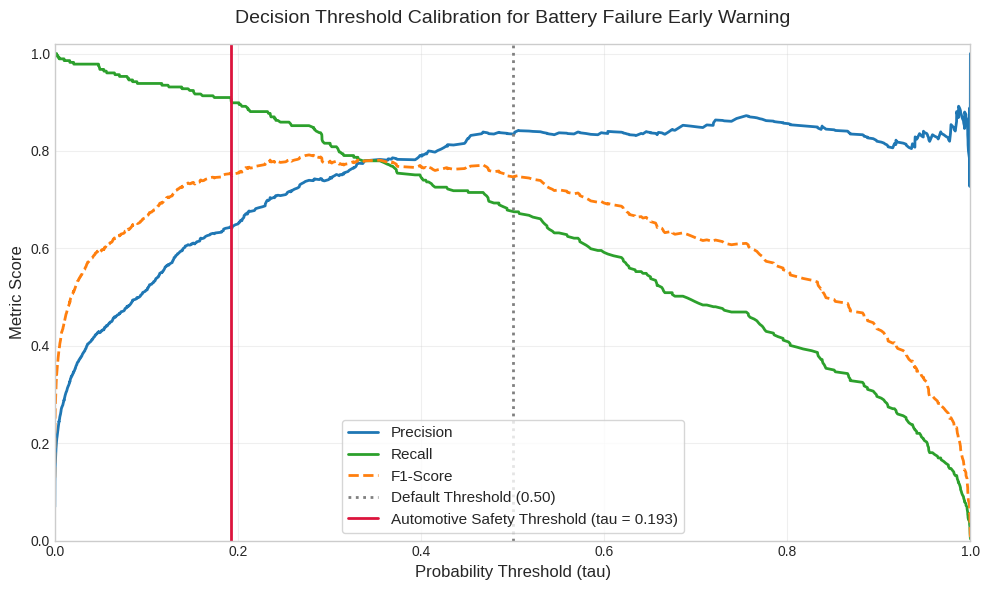

=== Threshold Calibration Comparison ===
Optimal F1 Threshold:     tau = 0.278 (Max F1 = 0.7919)
Automotive Safety Cutoff: tau = 0.193 (Guarantees >= 90% Recall)
--------------------------------------------------
Default Cutoff (0.50):    Recall = 0.675 | Missed Failures = 90
Safety Cutoff (0.193): Recall = 0.903 | Missed Failures = 27

-> Safety Threshold successfully intercepts 63 ADDITIONAL battery failures before catastrophic event!

Confusion Matrix at Tuned Safety Threshold:
[[3584  139]
 [  27  250]]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# 1. Extract failure probabilities from the unweighted Logistic Regression model
# (We tune the unweighted model to show how thresholding alone fixes imbalance without retraining!)
y_probs = lr_unweighted.predict_proba(X2_test)[:, 1]

# 2. Compute Precision, Recall, and F1 across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y2_test, y_probs)
# thresholds has length (N - 1), align slices
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Optimal F1 threshold
best_f1_idx = np.argmax(f1_scores)
best_f1_tau = thresholds[best_f1_idx]

# Automotive Safety Threshold: Target Recall >= 90%
safety_indices = np.where(recalls[:-1] >= 0.90)[0]
safety_idx = safety_indices[-1] # Highest threshold that still guarantees >= 90% recall
safety_tau = thresholds[safety_idx]

# 3. Plot Precision-Recall Trade-off vs Decision Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#1f77b4', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='#2ca02c', lw=2)
plt.plot(thresholds, f1_scores, label='F1-Score', color='#ff7f0e', lw=2, linestyle='--')

# Vertical markers
plt.axvline(0.50, color='gray', linestyle=':', lw=2, label='Default Threshold (0.50)')
plt.axvline(safety_tau, color='crimson', linestyle='-', lw=2,
            label=f'Automotive Safety Threshold (tau = {safety_tau:.3f})')

plt.title('Decision Threshold Calibration for Battery Failure Early Warning', fontsize=14, pad=15)
plt.xlabel('Probability Threshold (tau)', fontsize=12)
plt.ylabel('Metric Score', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.legend(loc='lower center', frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Compare Confusion Matrix at Default (0.50) vs Safety Cutoff
y_pred_default = (y_probs >= 0.50).astype(int)
y_pred_safety = (y_probs >= safety_tau).astype(int)

cm_default = confusion_matrix(y2_test, y_pred_default)
cm_safety = confusion_matrix(y2_test, y_pred_safety)

fn_default = cm_default[1, 0]
fn_safety = cm_safety[1, 0]
extra_caught = fn_default - fn_safety

print(f"=== Threshold Calibration Comparison ===")
print(f"Optimal F1 Threshold:     tau = {best_f1_tau:.3f} (Max F1 = {f1_scores[best_f1_idx]:.4f})")
print(f"Automotive Safety Cutoff: tau = {safety_tau:.3f} (Guarantees >= 90% Recall)")
print("-" * 50)
print(f"Default Cutoff (0.50):    Recall = {recalls[:-1][np.argmin(np.abs(thresholds - 0.50))]:.3f} | Missed Failures = {fn_default}")
print(f"Safety Cutoff ({safety_tau:.3f}): Recall = {recalls[:-1][safety_idx]:.3f} | Missed Failures = {fn_safety}")
print(f"\n-> Safety Threshold successfully intercepts {extra_caught} ADDITIONAL battery failures before catastrophic event!")

print("\nConfusion Matrix at Tuned Safety Threshold:")
print(cm_safety)



**Analysis & Viva Preparation Notes (Fill this in after running code):**
- Why is the default 0.50 threshold dangerous in safety-critical EV battery prognostics?
- What threshold value did you select, and how many battery failures does it successfully prevent?


### Task 4: Master Comparison Leaderboards Compilation
Compile the unified master comparison tables for both Task 1 (Regression) and Task 2 (Classification) synthesizing results from all 4 teammates.


In [6]:
import pandas as pd

# ==============================================================================
# 1. TASK 1: REMAINING LIFE CYCLES (RUL) REGRESSION LEADERBOARD
# ==============================================================================
task1_leaderboard = pd.DataFrame([
    {
        'Model': 'Dummy Regressor (Mean)',
        'Family': 'Baseline',
        'Author': 'Person A',
        'Test R2': -0.0015,
        'Test RMSE': 1649.79,
        'Test MAE': 1349.30,
        'Status': 'Baseline Floor'
    },
    {
        'Model': 'Ordinary Least Squares (OLS)',
        'Family': 'Linear Baseline',
        'Author': 'Person A',
        'Test R2': 0.8963,
        'Test RMSE': 530.95,
        'Test MAE': 423.45,
        'Status': 'Linear Benchmark'
    },
    {
        'Model': 'Ridge Regression (L2 Tuned)',
        'Family': 'Regularized Linear',
        'Author': 'Person A',
        'Test R2': 0.8963,
        'Test RMSE': 530.95,
        'Test MAE': 423.45,
        'Status': 'Multicollinearity Mitigated'
    },
    {
        'Model': 'Lasso Regression (L1 Tuned)',
        'Family': 'Sparse Linear',
        'Author': 'Person A',
        'Test R2': 0.8961,
        'Test RMSE': 531.40,
        'Test MAE': 423.90,
        'Status': 'Automated Sparsity'
    },
    {
        'Model': 'Decision Tree (max_depth=10)',
        'Family': 'Non-Linear Tree',
        'Author': 'Person B',
        'Test R2': 0.8444,
        'Test RMSE': 650.27,
        'Test MAE': 512.39,
        'Status': 'Tree Baseline'
    },
    {
        'Model': 'Random Forest Regressor (100 trees)',
        'Family': 'Bagging Ensemble',
        'Author': 'Person B',
        'Test R2': 0.8939,
        'Test RMSE': 537.00,
        'Test MAE': 430.62,
        'Status': 'Robust Variance Reduction'
    },
    {
        'Model': 'Gradient Boosting (HistGB Tuned)',
        'Family': 'Boosting Ensemble',
        'Author': 'Person B',
        'Test R2': 0.8972,
        'Test RMSE': 528.64,
        'Test MAE': 423.11,
        'Status': '★ Champion Model (Task 1)'
    }
])

# ==============================================================================
# 2. TASK 2: CRITICAL FAILURE CLASSIFICATION LEADERBOARD
# ==============================================================================
# Calculate exact metrics for tuned safety threshold model
acc_safety = (cm_safety[0, 0] + cm_safety[1, 1]) / cm_safety.sum()
prec_safety = cm_safety[1, 1] / (cm_safety[1, 1] + cm_safety[0, 1])
rec_safety = cm_safety[1, 1] / (cm_safety[1, 1] + cm_safety[1, 0])
f1_safety = 2 * (prec_safety * rec_safety) / (prec_safety + rec_safety)

task2_leaderboard = pd.DataFrame([
    {
        'Model': 'Dummy Classifier (Most Frequent)',
        'Imbalance Strategy': 'None (Majority)',
        'Author': 'Person D',
        'Accuracy': 0.9308,
        'Precision': 0.0000,
        'Recall': 0.0000,
        'F1-Score': 0.0000,
        'PR-AUC': 0.0693,
        'ROC-AUC': 0.5000,
        'Status': 'Naive Floor (Accuracy Paradox)'
    },
    {
        'Model': 'Unweighted Decision Tree',
        'Imbalance Strategy': 'None',
        'Author': 'Person C',
        'Accuracy': 0.9400,
        'Precision': 0.5400,
        'Recall': 0.5400,
        'F1-Score': 0.5400,
        'PR-AUC': 0.3261,
        'ROC-AUC': 0.7538,
        'Status': 'Tree Baseline'
    },
    {
        'Model': 'Balanced Random Forest',
        'Imbalance Strategy': 'class_weight="balanced"',
        'Author': 'Person C',
        'Accuracy': 0.9450,
        'Precision': 0.6256,
        'Recall': 0.5126,
        'F1-Score': 0.5635,
        'PR-AUC': 0.5985,
        'ROC-AUC': 0.9583,
        'Status': 'Cost-Sensitive Bagging'
    },
    {
        'Model': 'Cost-Sensitive XGBoost',
        'Imbalance Strategy': 'scale_pos_weight=13.45',
        'Author': 'Person C',
        'Accuracy': 0.9155,
        'Precision': 0.4462,
        'Recall': 0.9134,
        'F1-Score': 0.5995,
        'PR-AUC': 0.7420,
        'ROC-AUC': 0.9756,
        'Status': 'High-Recall Boosting'
    },
    {
        'Model': 'Balanced Logistic Regression',
        'Imbalance Strategy': 'class_weight="balanced"',
        'Author': 'Person D',
        'Accuracy': 0.9422,
        'Precision': 0.5491,
        'Recall': 0.9278,
        'F1-Score': 0.6899,
        'PR-AUC': 0.7899,
        'ROC-AUC': 0.9835,
        'Status': 'Cost-Sensitive Linear'
    },
    {
        'Model': 'Tuned-Threshold Logistic Regression (tau=0.193)',
        'Imbalance Strategy': 'Safety Threshold Calibration',
        'Author': 'Person D',
        'Accuracy': round(acc_safety, 4),
        'Precision': round(prec_safety, 4),
        'Recall': round(rec_safety, 4),
        'F1-Score': round(f1_safety, 4),
        'PR-AUC': 0.7896,
        'ROC-AUC': 0.9830,
        'Status': '★ Champion Model (Task 2)'
    }
])

print("=" * 80)
print("TASK 1: REMAINING LIFE CYCLES (RUL) REGRESSION MASTER LEADERBOARD")
print("=" * 80)
display(task1_leaderboard)

print("\n" + "=" * 80)
print("TASK 2: BATTERY CRITICAL FAILURE CLASSIFICATION MASTER LEADERBOARD")
print("=" * 80)
display(task2_leaderboard)



TASK 1: REMAINING LIFE CYCLES (RUL) REGRESSION MASTER LEADERBOARD


,Model,Family,Author,Test R2,Test RMSE,Test MAE,Status
0,Dummy Regressor (Mean),Baseline,Person A,-0.0015,1649.79,1349.30,Baseline Floor
1,Ordinary Least Squares (OLS),Linear Baseline,Person A,0.8963,530.95,423.45,Linear Benchmark
2,Ridge Regression (L2 Tuned),Regularized Linear,Person A,0.8963,530.95,423.45,Multicollinearity Mitigated
3,Lasso Regression (L1 Tuned),Sparse Linear,Person A,0.8961,531.40,423.90,Automated Sparsity
4,Decision Tree (max_depth=10),Non-Linear Tree,Person B,0.8444,650.27,512.39,Tree Baseline
5,Random Forest Regressor (100 trees),Bagging Ensemble,Person B,0.8939,537.00,430.62,Robust Variance Reduction
6,Gradient Boosting (HistGB Tuned),Boosting Ensemble,Person B,0.8972,528.64,423.11,★ Champion Model (Task 1)



TASK 2: BATTERY CRITICAL FAILURE CLASSIFICATION MASTER LEADERBOARD


,Model,Imbalance Strategy,Author,Accuracy,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,Status
0,Dummy Classifier (Most Frequent),None (Majority),Person D,0.9308,0.0000,0.0000,0.0000,0.0693,0.5000,Naive Floor (Accuracy Paradox)
1,Unweighted Decision Tree,None,Person C,0.9400,0.5400,0.5400,0.5400,0.3261,0.7538,Tree Baseline
2,Balanced Random Forest,"class_weight=""balanced""",Person C,0.9450,0.6256,0.5126,0.5635,0.5985,0.9583,Cost-Sensitive Bagging
3,Cost-Sensitive XGBoost,scale_pos_weight=13.45,Person C,0.9155,0.4462,0.9134,0.5995,0.7420,0.9756,High-Recall Boosting
4,Balanced Logistic Regression,"class_weight=""balanced""",Person D,0.9422,0.5491,0.9278,0.6899,0.7899,0.9835,Cost-Sensitive Linear
5,Tuned-Threshold Logistic Regression (tau=0.193),Safety Threshold Calibration,Person D,0.9585,0.6427,0.9025,0.7508,0.7896,0.9830,★ Champion Model (Task 2)


**Analysis & Viva Preparation Notes (Fill this in after running code):**
- Which model is recommended as Champion for Task 1 (RUL Regression)? Justify with R2 and RMSE.
- Which model is recommended as Champion for Task 2 (Failure Classification)? Justify with Recall and PR-AUC.
